# Week 16 — Supersonic Shape Optimization with Verified CFD
**FlowMLLab · Ehsan Roohi · MIE 690A**

[Open in Colab](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week16/W16_Supersonic_Shape_Optimization.ipynb)

The main student dataset contains 44 newly computed SU2 8.0.1 cases with numerical and full-field physical checks. A separately identified neural model uses only its 24 training cases. Historical SU2 8.5.0 data and weights remain available for an audit lesson: their small residuals did not reveal local total-enthalpy defects. You will distinguish analytical verification, neural prediction accuracy and direct design checks; the research appendix explains why attempted experimental CFD validation remains unaccepted.

**Claim boundary:** the computed target is near-field peak pressure at $r/L=0.5$. This notebook does not compute atmospheric propagation or PLdB, and its axisymmetric body is not TMS-10. Read [the assignment](ASSIGNMENT.md), [the model validation guide](MODEL_VALIDATION_GUIDE.md), and [the NASA reference walkthrough](NASA_REFERENCE_GUIDE.md) for assessed extensions and the distinction between analytical, experimental and learned-model checks.

Run from a clone of FlowMLLab. Dependencies for the data-based lab: numpy, scipy, scikit-learn, pandas, matplotlib. Gmsh and SU2 are required only for regenerating CFD.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1: sparse checkout for Week 16
from pathlib import Path
import sys, json, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'qa/week16/learning.py').exists()), None)
if ROOT is None:
    import importlib.util, subprocess
    if importlib.util.find_spec('google.colab') is not None:
        target=Path('/content/FlowMLLab_week16')
        if not target.exists():
            subprocess.run(['git','clone','--depth','1','--filter=blob:none','--sparse','https://github.com/Ehsan-Roohi/FlowMLLab.git',str(target)],check=True)
            subprocess.run(['git','-C',str(target),'sparse-checkout','set','qa/week16','results/week16_lowboom','notebooks/week16','cases/week16_lowboom/reference'],check=True)
        ROOT=target
    else:
        raise RuntimeError('Clone FlowMLLab, then open this notebook inside the checkout.')
sys.path.insert(0, str(ROOT/'qa/week16'))
from cfd import radius, VOLUME
from learning import Surrogate, optimize
E = ROOT/'results/week16_lowboom'
historical_data = np.load(E/'dataset.npz')
data = np.load(E/'reference/clean_dataset_v801.npz')
clean_campaign = json.loads((E/'reference/clean_campaign_audit.json').read_text())
assert clean_campaign['passed'] and clean_campaign['cases']==44
assert hashlib.sha256((E/'reference/clean_dataset_v801.npz').read_bytes()).hexdigest()==clean_campaign['dataset_sha256']
summary = json.loads((E/'summary.json').read_text())
assert hashlib.sha256((E/'dataset.npz').read_bytes()).hexdigest() == summary['dataset_sha256']
print('Clean student dataset verified:', clean_campaign['dataset_sha256'])
print('CFD cases:', len(data['parameters']))
print('Clean solver version:', clean_campaign['solver_version'])
print('Clean solver binary SHA-256:', clean_campaign['identity']['solver_binary_sha256'])
display(pd.Series(json.loads((E/'software_versions.json').read_text()), name='Historical SU2 8.5.0 generation environment'))

Clean student dataset verified: 03790fc0b8e2034aed66b3e7ec3ffbdd3a08306b487705b54bb839bfa869e58b
CFD cases: 44
Clean solver version: 8.0.1
Clean solver binary SHA-256: 9d75d6b1b862e6d3470c80ecab2cfa09fac3d54943f6d6d610bc36cd7ef71351


numpy                                                       2.3.5
scipy                                                      1.17.0
scikit-learn                                                1.8.0
gmsh                                                       4.15.2
matplotlib                                                 3.10.8
nbformat                                                   5.11.1
nbclient                                                   0.11.0
meshio                                                      5.3.5
python          3.12.14 (main, Aug 25 2026, 14:00:49) [Clang 2...
SU2                             8.5.0 official linux64-omp binary
su2_sha256      0b8b343f41a4c441ab9900a597de6d3b56eca688157e3f...
Name: Historical SU2 8.5.0 generation environment, dtype: object

## 1. Geometry and volume
For $s=x/L$, define $f(s)=\sin(\pi s)\exp[a(2s-1)+b\cos(2\pi s)]$ and $r(s)=c f(s)$.
The constraint gives $c=\sqrt{V/(\pi L\int_0^1 f(s)^2\,ds)}$.

These are three-dimensional bodies of revolution. The two-dimensional mesh is a meridional representation of the axisymmetric equations, including their radial source terms.

In [2]:
x = np.linspace(0,1,2001)
fig,ax = plt.subplots(figsize=(9,2.5))
checks=[]
for a,b in [(0,0),(.3,.15),(-.3,-.15)]:
    r=radius(x,a,b)
    line,=ax.plot(x,r,label=f'a={a}, b={b}')
    ax.plot(x,-r,color=line.get_color())
    volume=np.pi*np.trapezoid(r*r,x)
    checks.append({'a':a,'b':b,'volume':volume,'relative_error':abs(volume/VOLUME-1)})
ax.set(xlabel='x/L',ylabel='r/L',aspect='equal');ax.legend(ncol=3,loc='upper center',bbox_to_anchor=(.5,1.5));plt.show()
display(pd.DataFrame(checks))
assert max(r['relative_error'] for r in checks)<1e-5

,a,b,volume,relative_error
0,0.0,0.00,0.005655,0.000000e+00
1,0.3,0.15,0.005655,2.209344e-14
2,-0.3,-0.15,0.005655,9.214851e-15


## 2. Accepting the CFD data
Pressure is reconstructed as $p=(\gamma-1)[\rho E-(\rho u)^2/(2\rho)-(\rho v)^2/(2\rho)]$.
The pressure coefficient is $C_p=(p-p_\infty)/(\tfrac12\gamma p_\infty M^2)$.

We separately check an independent cone solution, discrete convergence, mesh sensitivity and domain sensitivity. The cone benchmark is not a complete sonic-boom validation.

Historical SU2 8.5.0 numerical checks; physical acceptance is assessed separately below.


exact             {'shock_angle_deg': 34.03574212191822, 'pressu...
cfd_cp_mean                                                0.061387
relative_error                                             0.009957
wall_seconds                                              15.841388
passed                                                         True
dtype: object

baseline_peak_mesh_difference      0.024569
baseline_drag_mesh_difference      0.018995
baseline_wave_mesh_difference      0.038572
baseline_domain_peak_difference    0.001425
optimized_peak_mesh_difference     0.033157
optimized_drag_mesh_difference     0.026601
peak_reduction_fine                0.215391
peak_reduction_finer               0.208422
drag_change_fine                  -0.052827
drag_change_finer                 -0.045426
dtype: float64

,name,cells,iterations,residual_drop,drag_tail_relative_range
0,train_000,45408,501,12.858581,0.0
1,train_001,45408,501,12.936662,0.0
2,train_002,45408,501,12.864711,0.0
3,train_003,45408,501,12.973364,0.0
4,train_004,45408,501,12.932987,0.0
5,train_005,45408,501,12.938049,0.0
6,train_006,45408,501,12.935266,0.0
7,train_007,45408,501,12.939382,0.0


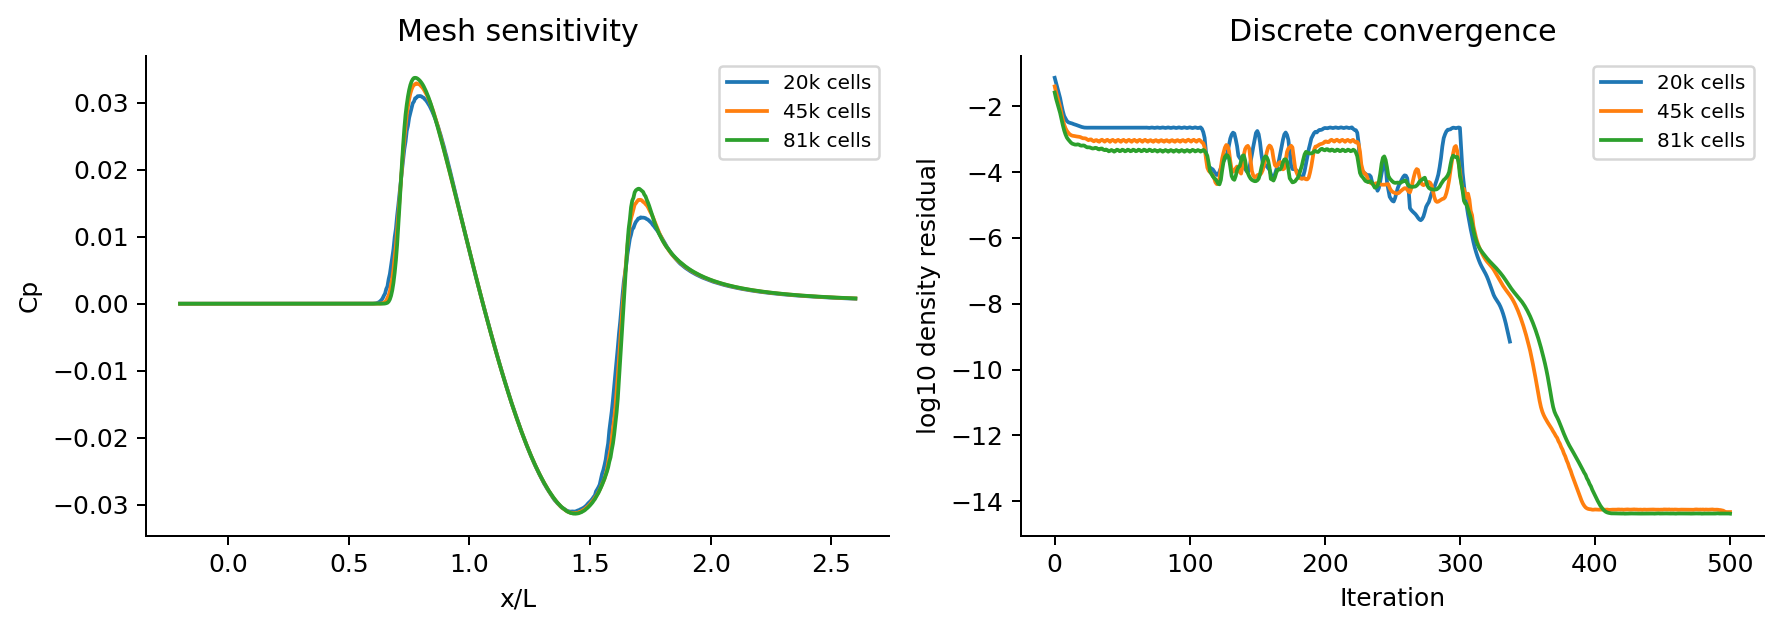

In [3]:
print('Historical SU2 8.5.0 numerical checks; physical acceptance is assessed separately below.')
display(pd.Series(summary['benchmark']))
display(pd.Series(summary['validation']))
cases = pd.read_csv(E/'case_metrics.csv')
assert len(cases)==44 and cases['converged'].all()
display(cases[['name','cells','iterations','residual_drop','drag_tail_relative_range']].head(8))
display(Image(filename=str(E/'numerical_verification.png')))

### Recompute the Taylor-Maccoll reference
The conical similarity equations are integrated from an oblique shock to the cone wall. A scalar root search adjusts the shock angle until the polar velocity vanishes at the 7-degree wall. This ODE calculation is independent of the SU2 finite-volume discretization. The SU2 8.0.1 comparison retains all three mesh levels, including any coarse-grid failure. It verifies cone wall pressure, not an off-body boom waveform.

In [4]:
from benchmark import cone_exact
exact=cone_exact(mach=1.8,theta_deg=7.)
display(pd.Series(exact,name='Independently integrated cone solution'))
assert abs(exact['cp']-summary['benchmark']['exact']['cp'])<1e-8
cone=json.loads((E/'reference/cone_refinement_v801.json').read_text())
display(pd.DataFrame([dict(level=r['level'],cells=r['mesh']['cells'],Cp=r['analytical_comparison']['cfd_cp_mean'],Cp_error_percent=100*r['analytical_comparison']['relative_error'],physical_pass=r['physical']['passed'],converged=r['numerical']['passed']) for r in cone['levels']]))
print('Last two mean-Cp change [%]:',100*cone['last_two_cp_relative_change'])
print('Refined-family gates:',cone['checks'])
assert cone['passed']
print('Coarse-grid Cp failure, if present, is retained; acceptance uses the declared refined-family criteria.')

shock_angle_deg    34.035742
pressure_ratio      1.140626
cp                  0.062004
Name: Independently integrated cone solution, dtype: float64

,level,cells,Cp,Cp_error_percent,physical_pass,converged
0,1,24000,0.059175,4.563228,True,True
1,2,96000,0.060667,2.156344,True,True
2,3,216000,0.061284,1.161628,True,True


Last two mean-Cp change [%]: 1.0064068206084114
Refined-family gates: {'all_three_levels_numerically_converged': True, 'all_three_levels_physically_admissible': True, 'finest_analytical_cp_error_below_3pct': True, 'last_two_mean_cp_change_below_3pct': True}
Coarse-grid Cp failure, if present, is retained; acceptance uses the declared refined-family criteria.


## 3. Frozen geometry split
POD and scalers are fitted on training cases only. Validation selects the design model. The test cases remain outside fitting and selection. Extrapolation extends parameter $b$ beyond the training interval. All splits belong to the same two-parameter geometry family.

In [5]:
display(pd.Series(data['splits']).value_counts().rename('Cases'))
fig,ax=plt.subplots(figsize=(7,4))
for split,marker in [('train','o'),('validation','s'),('test','^'),('extrapolation','x')]:
    mask=data['splits']==split
    ax.scatter(*data['parameters'][mask].T,label=split,marker=marker)
ax.set(xlabel='a',ylabel='b');ax.legend();plt.show()
assert len(set(data['names']))==44
assert len(np.unique(data['parameters'],axis=0))==44

train            24
test              8
validation        6
extrapolation     6
Name: Cases, dtype: int64

## 4. Compare ridge, a neural network and a Gaussian process
The POD expansion is $C_p(x;\theta)\approx\overline C_p(x)+\sum_{k=1}^{K}z_k(\theta)\phi_k(x)$.
Each model predicts the same modal coefficients and log pressure drag. This notebook reruns model fitting, not the expensive CFD campaign.

The MLP has two 32-neuron tanh hidden layers and a fixed MLP seed. The PCA automatic solver is not seeded, so refitting can change the complete pipeline; see the model validation guide. This is a teaching comparison, not a statistical architecture ranking. Record any optimizer warnings rather than suppressing them.

In [6]:
train=data['splits']=='train'
models={};scores=[]
for kind in ['ridge','mlp','gp']:
    model=Surrogate(kind).fit(data['parameters'][train],data['waveforms'][train],data['cd'][train])
    models[kind]=model
    for split in ['validation','test','extrapolation']:
        mask=data['splits']==split
        w,cd=model.predict(data['parameters'][mask]);truth=data['waveforms'][mask]
        scores.append(dict(model=kind,split=split,
            waveform_error=np.linalg.norm(w-truth)/np.linalg.norm(truth),
            peak_error=np.mean(abs(w.max(axis=1)/truth.max(axis=1)-1)),
            drag_error=np.mean(abs(cd/data['cd'][mask]-1))))
    print(kind,'training seconds:',round(model.seconds,3),'warnings:',model.fit_warnings)
scores=pd.DataFrame(scores)
display(scores)
val=scores[scores.split=='validation'].copy()
selected=val.loc[(val.peak_error+val.drag_error).idxmin(),'model']
print('Validation-selected model:',selected)

ridge training seconds: 0.001 warnings: []


mlp training seconds: 0.246 warnings: []
gp training seconds: 0.093 warnings: []


,model,split,waveform_error,peak_error,drag_error
0,ridge,validation,0.086446,0.053378,0.052008
1,ridge,test,0.113314,0.074016,0.079214
2,ridge,extrapolation,0.360857,0.029879,0.397603
3,mlp,validation,0.039744,0.014604,0.021282
4,mlp,test,0.055614,0.023460,0.026215
5,mlp,extrapolation,0.334850,0.074019,0.214086
6,gp,validation,0.043500,0.019438,0.016594
7,gp,test,0.085653,0.028401,0.019718
8,gp,extrapolation,0.695019,0.267619,0.143973


Validation-selected model: mlp


In [7]:
test=np.where(data['splits']=='test')[0]
fig,axs=plt.subplots(2,2,figsize=(10,6))
for ax,i in zip(axs.flat,test[:4]):
    ax.plot(data['x'],data['waveforms'][i],'k',lw=2,label='SU2')
    for kind,model in models.items():
        w,_=model.predict(data['parameters'][i]);ax.plot(data['x'],w[0],label=kind)
    ax.set(title=str(data['names'][i]),xlabel='x/L',ylabel='Cp')
axs[0,0].legend();fig.tight_layout();plt.show()

### Primary retained neural model: clean CFD labels
All 44 original geometries were recomputed with official SU2 8.0.1 and passed the declared numerical and full-field physical checks. A new model was fitted once on the 24 training cases, with 12 full-SVD POD modes and the fixed 32–32 tanh architecture. The following cell reloads its portable weights without fitting. Validation, test and extrapolation cases do not enter this fit. Previously examined geometries and existing finer solutions make this a retrospective computational check, not a new blind experiment.

In [8]:
from clean_model_v801 import audit as clean_model_audit
from freeze_model import FrozenSurrogate
clean_audit=clean_model_audit(write=False)
assert clean_audit['passed']
clean_model=FrozenSurrogate(E/'reference/clean_model_v801.npz')
keys=['wave_relative_l2','peak_mean_relative_error','drag_mean_relative_error','worst_case_wave_relative_l2']
display(pd.DataFrame({split:{k:100*v[k] for k in keys} for split,v in clean_audit['same_mesh'].items()}).T)
display(pd.Series({k:100*clean_audit['finer_mesh'][k] for k in keys},name='Clean neural model versus finer CFD [%]'))
print('Checkpoint SHA-256:',clean_audit['checkpoint_sha256'])
print('Training warnings:',clean_audit['training_log']['warnings'])
with np.load(E/'reference/weakwall_checkpoint_test.npz') as fine:
    np.testing.assert_array_equal(fine['parameters'],data['parameters'][test])
    predicted,_=clean_model.predict(fine['parameters'])
    fig,axs=plt.subplots(4,2,figsize=(11,12))
    for j,ax in enumerate(axs.flat):
        ax.plot(data['x'],data['waveforms'][test[j]],label='Clean training-resolution CFD')
        ax.plot(fine['x'],fine['actual'][j],label='Finer CFD')
        ax.plot(fine['x'],predicted[j],'--',label='New retained neural model')
        ax.set(title=str(fine['names'][j]),xlabel='x/L',ylabel='Cp')
    axs.flat[0].legend(fontsize=7);fig.tight_layout();plt.show()
print('The historical optimizer candidate below was proposed by a different model.')

{
  "same_mesh": {
    "train": {
      "cases": 24,
      "wave_relative_l2": 0.003131552156784597,
      "peak_mean_relative_error": 0.0018864653827419299,
      "drag_mean_relative_error": 0.001115257534869185,
      "per_case_wave_relative_l2": [
        0.002811902992416999,
        0.003799682819320964,
        0.0021024445763336737,
        0.002701757376173541,
        0.002527232585374775,
        0.002448143577049044,
        0.0037103003572300764,
        0.0029115057255436542,
        0.0047293579291859756,
        0.004713889026794558,
        0.002324811199100601,
        0.0029883168859729543,
        0.004029718882236808,
        0.0014275221062440115,
        0.0031624550414551776,
        0.002356361630358421,
        0.006477148367128377,
        0.002556068683520883,
        0.002380946853442804,
        0.002279283560032543,
        0.0023002184718990794,
        0.004694594985268965,
        0.002497241130246569,
        0.0018907443875211003
      ],
      "worst

,wave_relative_l2,peak_mean_relative_error,drag_mean_relative_error,worst_case_wave_relative_l2
train,0.313155,0.188647,0.111526,0.647715
validation,3.935299,1.602248,2.254112,6.343273
test,5.369331,1.405634,2.559492,11.775113
extrapolation,34.286248,6.831286,22.388922,43.189953


wave_relative_l2                7.203598
peak_mean_relative_error        2.237324
drag_mean_relative_error        2.273959
worst_case_wave_relative_l2    15.371589
Name: Clean neural model versus finer CFD [%], dtype: float64

Checkpoint SHA-256: 4e45d142558036397e179255b5141ac72dce135453e88fc3c2e7deb6df9a90e3
Training warnings: []


The historical optimizer candidate below was proposed by a different model.


### Independent audit of the archived prediction snapshot
The following comparison uses recovered **frozen predictions**, not the models refitted above. Eight held-out geometries were evaluated against archived finer-mesh CFD waveforms. The script verifies the original evidence hashes, geometry identities and coordinates, and exact equality of the two stored copies of the predictions.

It reports the aggregate waveform error and the worst individual geometry separately. Passing an aggregate 10% threshold does not mean every geometry is below 10%. The compact arrays allow numerical comparisons to be checked; recovering them does not independently recover the original solver logs or prove the chronology of the runs. This is a refit of this teaching repository's architecture, not the original author's full-aircraft neural network.

,paired_coarse_mesh,finer_mesh
Error [%],,
wave_relative_l2,5.051082,7.154137
peak_mean_relative_error,2.207042,3.446863
drag_mean_relative_error,2.204196,1.693583
worst_case_wave_relative_l2,11.864281,15.798427


,geometry,finer_wave_error_percent
0,test_000,15.798427
1,test_001,5.963057
2,test_002,6.158425
3,test_003,6.912808
4,test_004,1.820338
5,test_005,3.965770
6,test_006,7.958371
7,test_007,7.840150


Coarse/finer CFD waveform difference [%]: 3.863101291437738
Aggregate acceptance checks: {'wave_relative_l2': True, 'peak_mean_relative_error': True, 'drag_mean_relative_error': True}


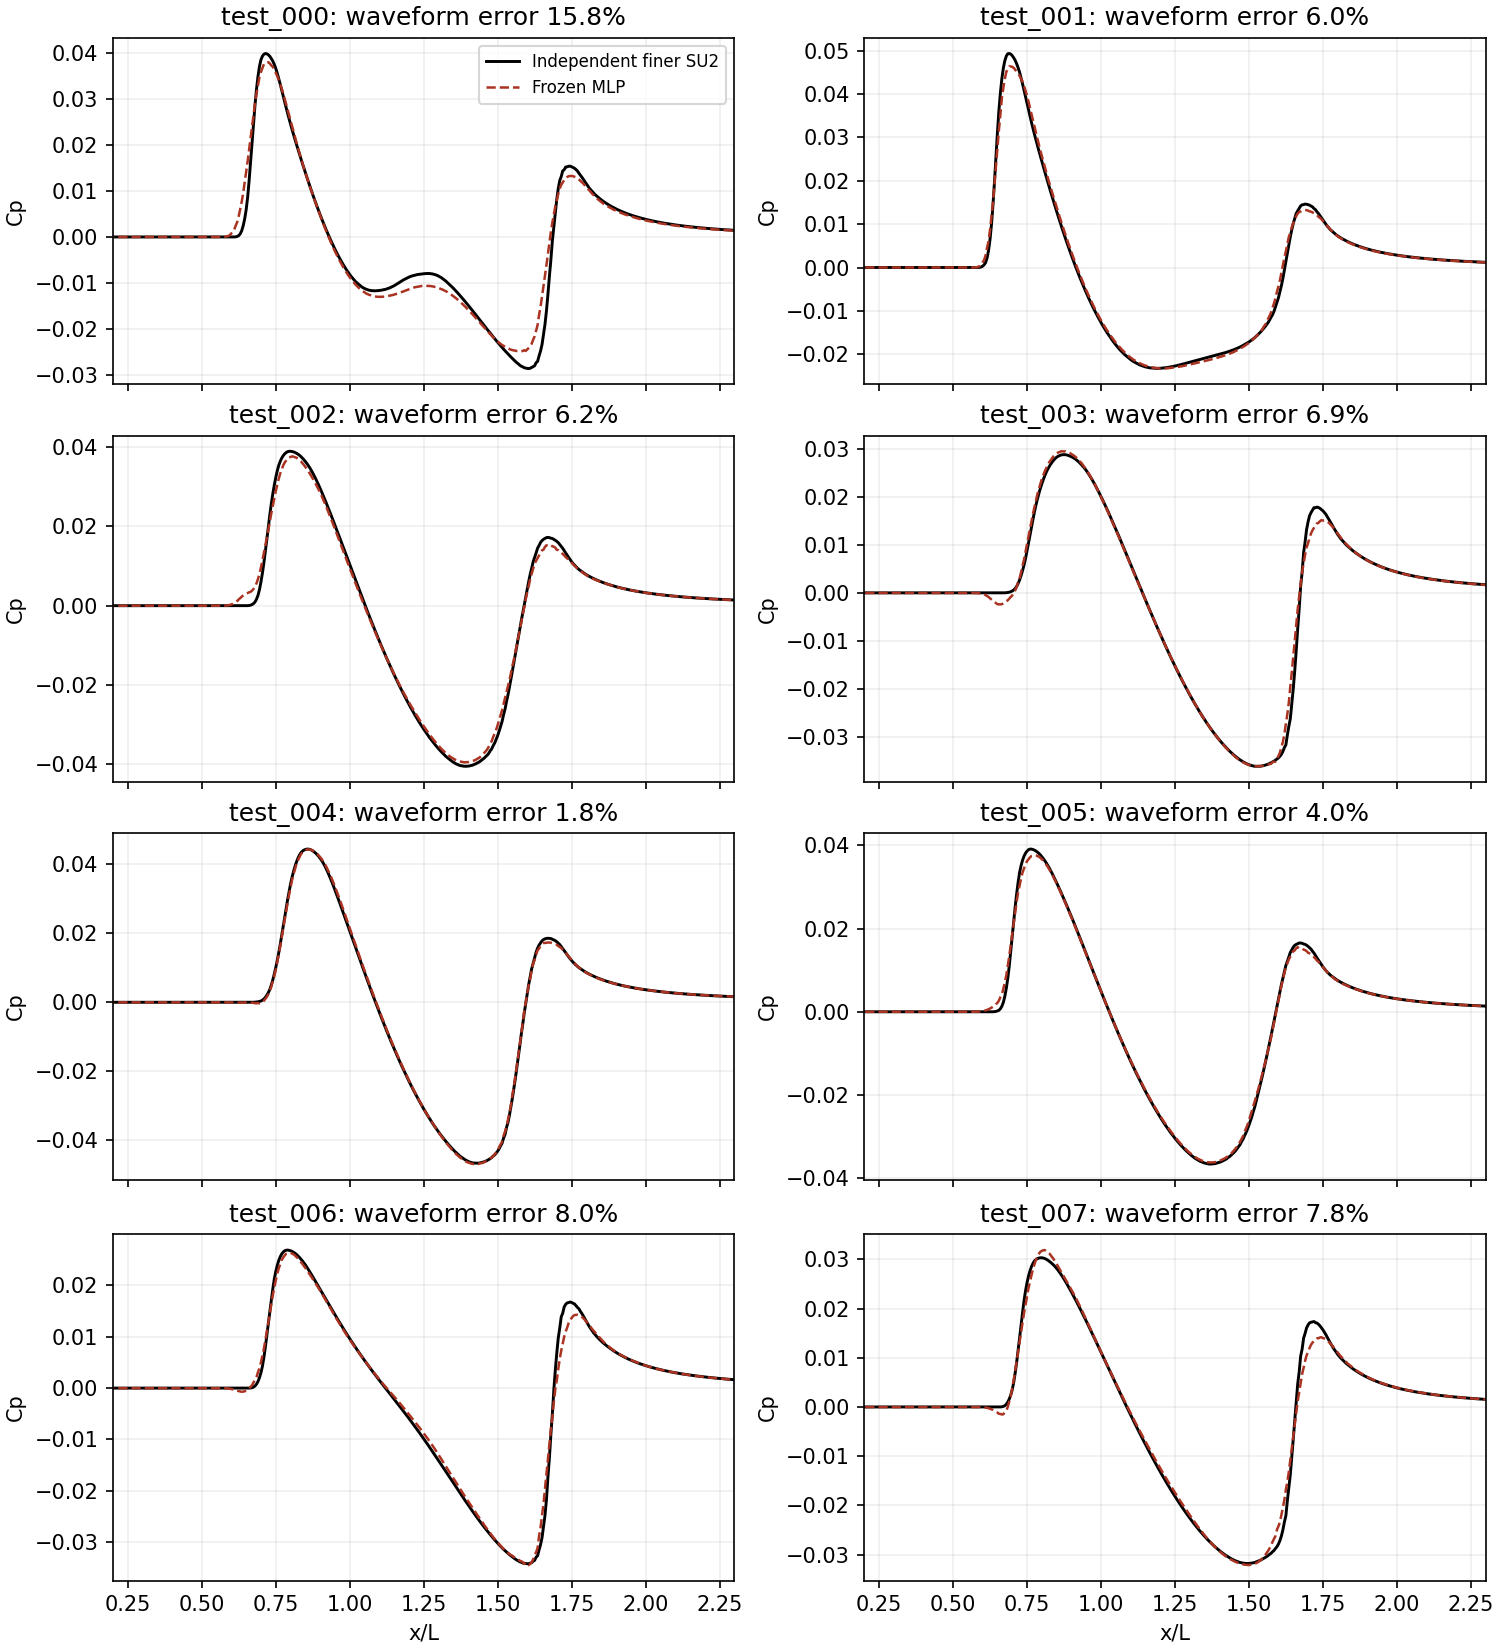

These archived predictions remain unchanged when the notebook refits its demonstration models.


In [9]:
from independent_audit_report import build_report
audit=build_report(write=False)
keys=['wave_relative_l2','peak_mean_relative_error','drag_mean_relative_error','worst_case_wave_relative_l2']
display(pd.DataFrame({label:{key:100*audit[label][key] for key in keys} for label in ['paired_coarse_mesh','finer_mesh']}).rename_axis('Error [%]'))
display(pd.DataFrame({'geometry':audit['names'],'finer_wave_error_percent':100*np.asarray(audit['finer_mesh']['per_case_wave_relative_l2'])}))
print('Coarse/finer CFD waveform difference [%]:',100*audit['coarse_to_finer_wave_relative_l2'])
print('Aggregate acceptance checks:',audit['checks'])
assert audit['passed']
display(Image(filename=str(E/'reference/independent_neural_test.png')))
print('These archived predictions remain unchanged when the notebook refits its demonstration models.')

### Use the retained portable neural checkpoint
The saved scaler, POD basis and network arrays form a separate deterministic refit. NumPy-only inference makes it usable without retraining. Its finer-CFD evaluation is retrospective because those reference labels were already available. Do not attribute the historical optimized design or the frozen-prediction audit above to this different fitted model. Inspect extrapolation errors as well as interpolation.

In [10]:
from freeze_model import FrozenSurrogate, audit as checkpoint_audit
frozen=FrozenSurrogate()
checkpoint=checkpoint_audit(write=False)
assert checkpoint['passed']
wave,drag=frozen.predict(data['parameters'][test])
print('Checkpoint identity:',checkpoint['checkpoint'])
scalar_errors=['wave_relative_l2','peak_mean_relative_error','drag_mean_relative_error','worst_case_wave_relative_l2']
error_table=pd.DataFrame({split:{key:100*values[key] for key in scalar_errors} for split,values in checkpoint['original_mesh'].items()}).T
error_table.columns=[key+' [%]' for key in error_table.columns]
display(error_table)
display(pd.Series({key+' [%]':100*checkpoint['finer_mesh'][key] for key in scalar_errors},name='Retrospective finer-CFD evaluation'))
fig,ax=plt.subplots(figsize=(9,3))
ax.plot(historical_data['x'],historical_data['waveforms'][test[0]],'k',label='Historical SU2 8.5.0 test case')
ax.plot(data['x'],wave[0],label='Retained checkpoint')
ax.set(xlabel='x/L',ylabel='Cp');ax.legend();plt.show()
print('This cell loads fixed weights. It does not fit or select a model.')

Checkpoint identity: {'sha256': '9b7a0f22671950c9ab1c86b3fc0790ba4d992a606ca429c60a2a2f18b92a6f72', 'github_blob_sha': '11337027584a29e44c78ef52e8dfd9c3cc034109', 'bytes': 73536}


,wave_relative_l2 [%],peak_mean_relative_error [%],drag_mean_relative_error [%],worst_case_wave_relative_l2 [%]
train,0.274016,0.118762,0.103147,0.481184
validation,2.896284,1.056947,1.622652,5.444030
test,4.100014,1.755662,2.578433,10.629309
extrapolation,34.162848,6.028376,22.144946,42.752751


wave_relative_l2 [%]                6.390342
peak_mean_relative_error [%]        1.927124
drag_mean_relative_error [%]        1.570816
worst_case_wave_relative_l2 [%]    14.626760
Name: Retrospective finer-CFD evaluation, dtype: float64

This cell loads fixed weights. It does not fit or select a model.


### Recomputed CFD with complete raw evidence
The eight known test geometries were also solved again at mesh level 2 with the retained checkpoint unchanged. Each prediction was saved before its solver run, and the complete meshes, configurations, histories and fields are archived. These repeated known geometries strengthen numerical reproducibility; they are not a new blind generalization set. The following cell independently recomputes errors from the compact distributed arrays.

wave_relative_l2 [%]                6.390342
peak_mean_relative_error [%]        1.927124
drag_mean_relative_error [%]        1.570816
worst_case_wave_relative_l2 [%]    14.626760
Name: New CFD / unchanged checkpoint, dtype: float64

,case,iterations,residual_log10,residual_drop
0,test_000,501,-14.445533,12.884476
1,test_001,501,-14.371163,12.811196
2,test_002,501,-14.442513,12.867396
3,test_003,501,-14.440803,12.868924
4,test_004,501,-14.444901,12.880639
5,test_005,501,-14.441702,12.864437
6,test_006,501,-14.433105,12.861791
7,test_007,501,-14.442299,12.859445


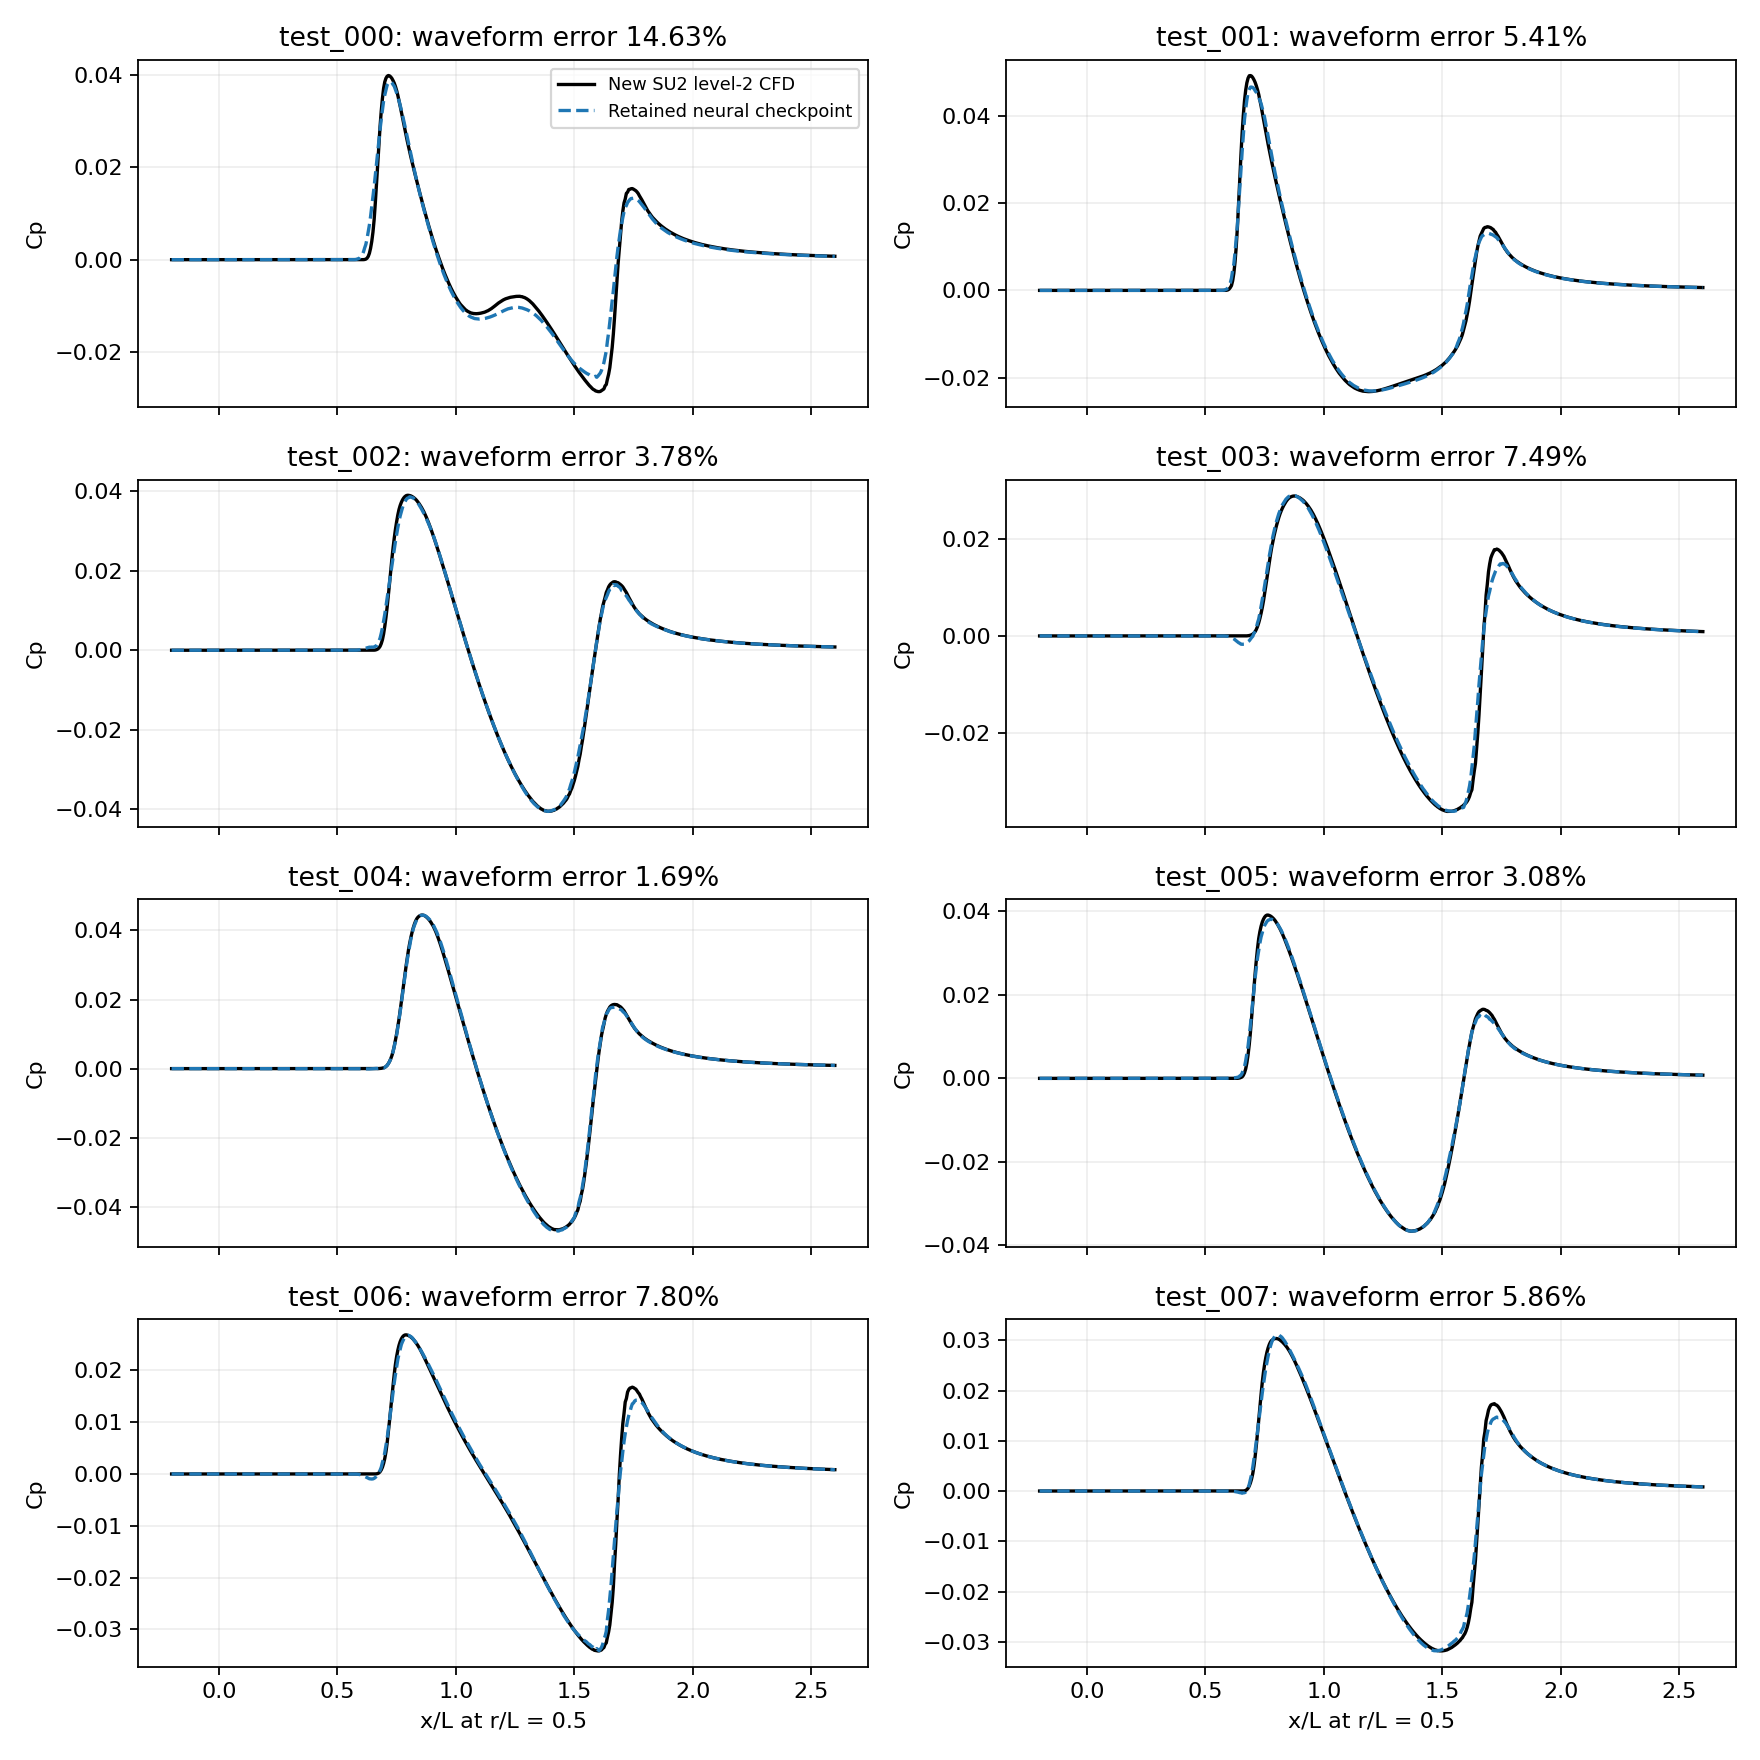

Retained portable checkpoint versus eight newly rerun level-2 CFD solutions, with complete raw convergence/field evidence.


In [11]:
from independent_audit_report import metrics as error_metrics
recomputed=json.loads((E/'reference/recomputed_checkpoint_audit.json').read_text())
path=E/'reference/recomputed_checkpoint_test.npz'
assert hashlib.sha256(path.read_bytes()).hexdigest()==recomputed['compact_arrays_sha256']
with np.load(path,allow_pickle=False) as labels:
    assert list(labels['names'])==recomputed['names']
    predicted,predicted_drag=frozen.predict(labels['parameters'])
    np.testing.assert_allclose(predicted,labels['predicted'],rtol=1e-12,atol=1e-14)
    measured=error_metrics(labels['predicted'],labels['actual'],labels['predicted_cd'],labels['actual_cd'])
for key in scalar_errors:
    assert np.isclose(measured[key],recomputed['metrics'][key],rtol=1e-10,atol=1e-12)
display(pd.Series({key+' [%]':100*measured[key] for key in scalar_errors},name='New CFD / unchanged checkpoint'))
display(pd.DataFrame([dict(case=row['name'],iterations=row['checks']['iterations'],residual_log10=row['checks']['density_residual_log10'],residual_drop=row['checks']['residual_drop']) for row in recomputed['run_evidence']]))
assert recomputed['passed']
display(Image(filename=str(E/'reference/recomputed_checkpoint_validation.png')))
print(recomputed['scope'])

### The physical audit changes what the numerical error means
Small residuals and accurate neural predictions do not establish physically reliable CFD labels. The archived 8.5.0 runs fail the full-field maximum total-enthalpy criterion at pointed body/axis nodes. The original training data remain unchanged. An official SU2 8.0.1 comparison uses the exact same eight meshes and configurations with the same retained neural weights; its full-field checks are reported separately. This is a controlled solver-version comparison at known geometries, not a new blind generalization test. See [the pointed-body investigation](POINTED_BODY_PHYSICS_AUDIT.md).

,case,max_h0_error_percent,physical_pass
0,checkpoint_test_000,17.151512,False
1,checkpoint_test_001,18.362284,False
2,checkpoint_test_002,18.680284,False
3,checkpoint_test_003,17.668406,False
4,checkpoint_test_004,18.696139,False
5,checkpoint_test_005,18.638164,False
6,checkpoint_test_006,17.967894,False
7,checkpoint_test_007,17.859751,False


wave_relative_l2 [%]                7.149905
peak_mean_relative_error [%]        2.634318
drag_mean_relative_error [%]        2.061515
worst_case_wave_relative_l2 [%]    15.970097
Name: Unchanged checkpoint versus SU2 8.0.1, dtype: float64

,case,max_h0_error_percent,max_density_over_bound,passed
0,test_000,4.766599,0.484905,True
1,test_001,3.899424,0.403488,True
2,test_002,3.192608,0.392951,True
3,test_003,4.800087,0.492496,True
4,test_004,3.402543,0.405396,True
5,test_005,3.167760,0.390516,True
6,test_006,4.941747,0.509841,True
7,test_007,4.713881,0.463022,True


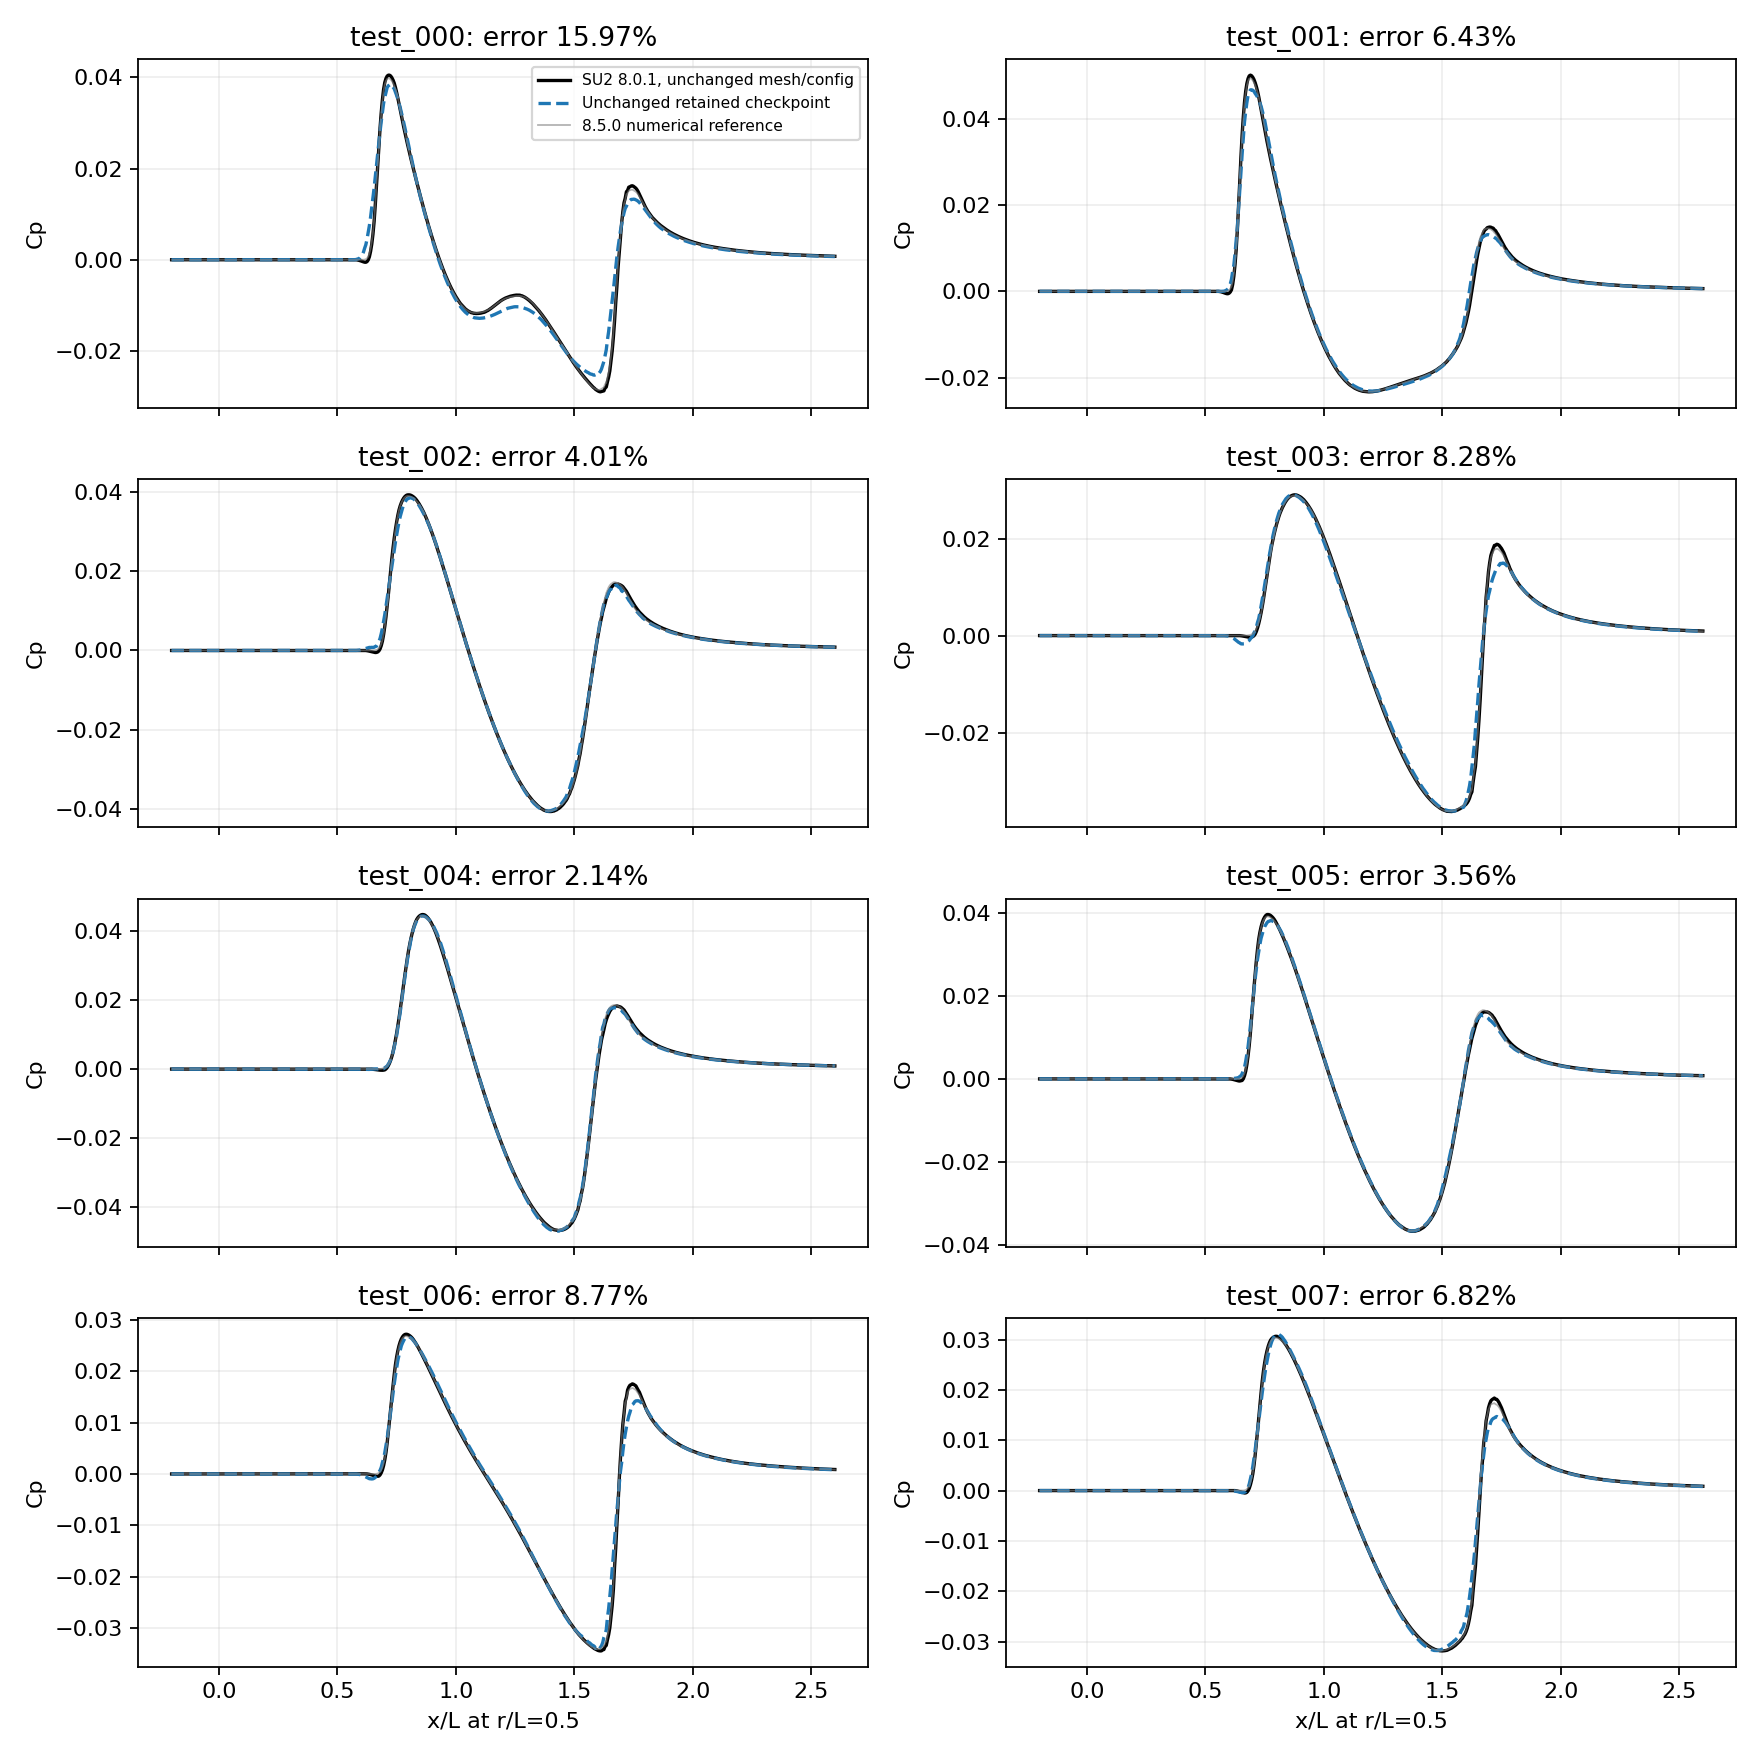

Worst individual error remains above 10%; the declared neural criteria are aggregate criteria.


In [12]:
historical_physics=json.loads((E/'reference/neural_physical_plausibility.json').read_text())
assert not historical_physics['passed']
display(pd.DataFrame([dict(case=r['case'],max_h0_error_percent=100*max(f['max_h0_relative_deviation'] for f in r['fields']),physical_pass=r['passed']) for r in historical_physics['runs']]))
accepted=json.loads((E/'reference/weakwall_checkpoint_audit.json').read_text())
path=E/'reference/weakwall_checkpoint_test.npz'
assert hashlib.sha256(path.read_bytes()).hexdigest()==accepted['compact_arrays_sha256']
with np.load(path,allow_pickle=False) as labels:
    assert list(labels['names'])==accepted['names']
    assert np.array_equal(labels['parameters'],data['parameters'][test])
    assert np.array_equal(labels['x'],data['x'])
    pw,pc=frozen.predict(labels['parameters'])
    np.testing.assert_allclose(pw,labels['predicted'],rtol=1e-12,atol=1e-14)
    np.testing.assert_allclose(pc,labels['predicted_cd'],rtol=1e-12,atol=1e-14)
    accepted_metrics=error_metrics(pw,labels['actual'],pc,labels['actual_cd'])
for key in scalar_errors:
    assert np.isclose(accepted_metrics[key],accepted['metrics'][key],rtol=1e-10,atol=1e-12)
display(pd.Series({key+' [%]':100*accepted_metrics[key] for key in scalar_errors},name='Unchanged checkpoint versus SU2 8.0.1'))
display(pd.DataFrame([dict(case=r['name'],max_h0_error_percent=100*max(f['max_h0_relative_deviation'] for f in r['checks']['physical']['fields']),max_density_over_bound=max(f['max_density_over_stagnation_bound'] for f in r['checks']['physical']['fields']),passed=r['checks']['passed']) for r in accepted['run_evidence']]))
assert accepted['passed'] and accepted['physical_and_convergence_pass']
display(Image(filename=str(E/'reference/weakwall_checkpoint_validation.png')))
print('Worst individual error remains above 10%; the declared neural criteria are aggregate criteria.')

## 5. Propose a design with the surrogate
The objective is minimum peak $C_p$ at $r/L=0.5$, with pressure drag at most 2% above baseline. Volume is enforced by parameterization. The retained optimization code uses a conservative search margin and checks feasibility explicitly after CFD. A predicted optimum is only a candidate.

Inspect the search implementation in `qa/week16/learning.py`; then compare the actual proposals below. The retained candidate is not replaced by a new unverified design during notebook execution.

In [13]:
baseline_evidence=json.loads((E/'reference/weakwall_design_audit.json').read_text())['runs'][0]
new_proposal=optimize(models[selected],write=False,baseline={'peak_cp':baseline_evidence['peak_cp'],'cd_pressure':baseline_evidence['cd_pressure']})
print('New refit proposal (not independently CFD-verified):',new_proposal['candidates'][0])
candidates=json.loads((E/'design_candidates.json').read_text())
print(candidates['objective'])
display(pd.DataFrame(candidates['candidates']))
print('Surrogate evaluations:',candidates['surrogate_evaluations'])
print('The following fresh CFD section evaluates these retained geometries directly; the portable checkpoint did not generate the historical optimizer proposal.')

New refit proposal (not independently CFD-verified): {'name': 'optimized', 'a': 0.2848683203867093, 'b': 0.0920969377450494, 'predicted_peak_cp': 0.027338190000993384, 'predicted_cd': 0.0013536909269114337}
minimize max Cp at r/L=0.5, pressure drag <= 1.02 baseline


,name,a,b,predicted_peak_cp,predicted_cd
0,optimized,0.324953,0.122378,0.026102,0.001318
1,alternative_1,0.319600,0.240472,0.027836,0.001330
2,alternative_2,0.286478,0.021652,0.027868,0.001337


Surrogate evaluations: 1005
The following fresh CFD section evaluates these retained geometries directly; the portable checkpoint did not generate the historical optimizer proposal.


## 6. Recompute and refine the retained candidate
Ten new SU2 8.0.1 runs check the original candidate geometries without changing the training data or retraining. The baseline and optimized candidate are solved at two mesh levels. Alternative shapes and Mach 1.7/1.9 cases have their own convergence and physical checks. The candidate must reduce the near-field peak by more than 5% and satisfy the actual pressure-drag constraint at both design-point meshes. Mesh differences are observed sensitivity, not a formal GCI.

,level,peak_reduction_percent,drag_change_percent,drag_ratio
0,1.5,21.187627,-3.797097,0.962029
1,2.0,20.664561,-3.521804,0.964782


,design,peak_mesh_change_percent,drag_mesh_change_percent,wave_mesh_change_percent
0,baseline,2.403148,0.979781,3.586262
1,optimized,3.046613,1.262327,5.394599


ten_runs_converged_and_physically_plausible        True
peak_reduction_above_5pct_at_both_design_meshes    True
drag_ratio_at_most_1p02_at_both_design_meshes      True
both_peak_mesh_changes_below_5pct                  True
both_drag_mesh_changes_below_3pct                  True
Name: Fresh design acceptance, dtype: bool

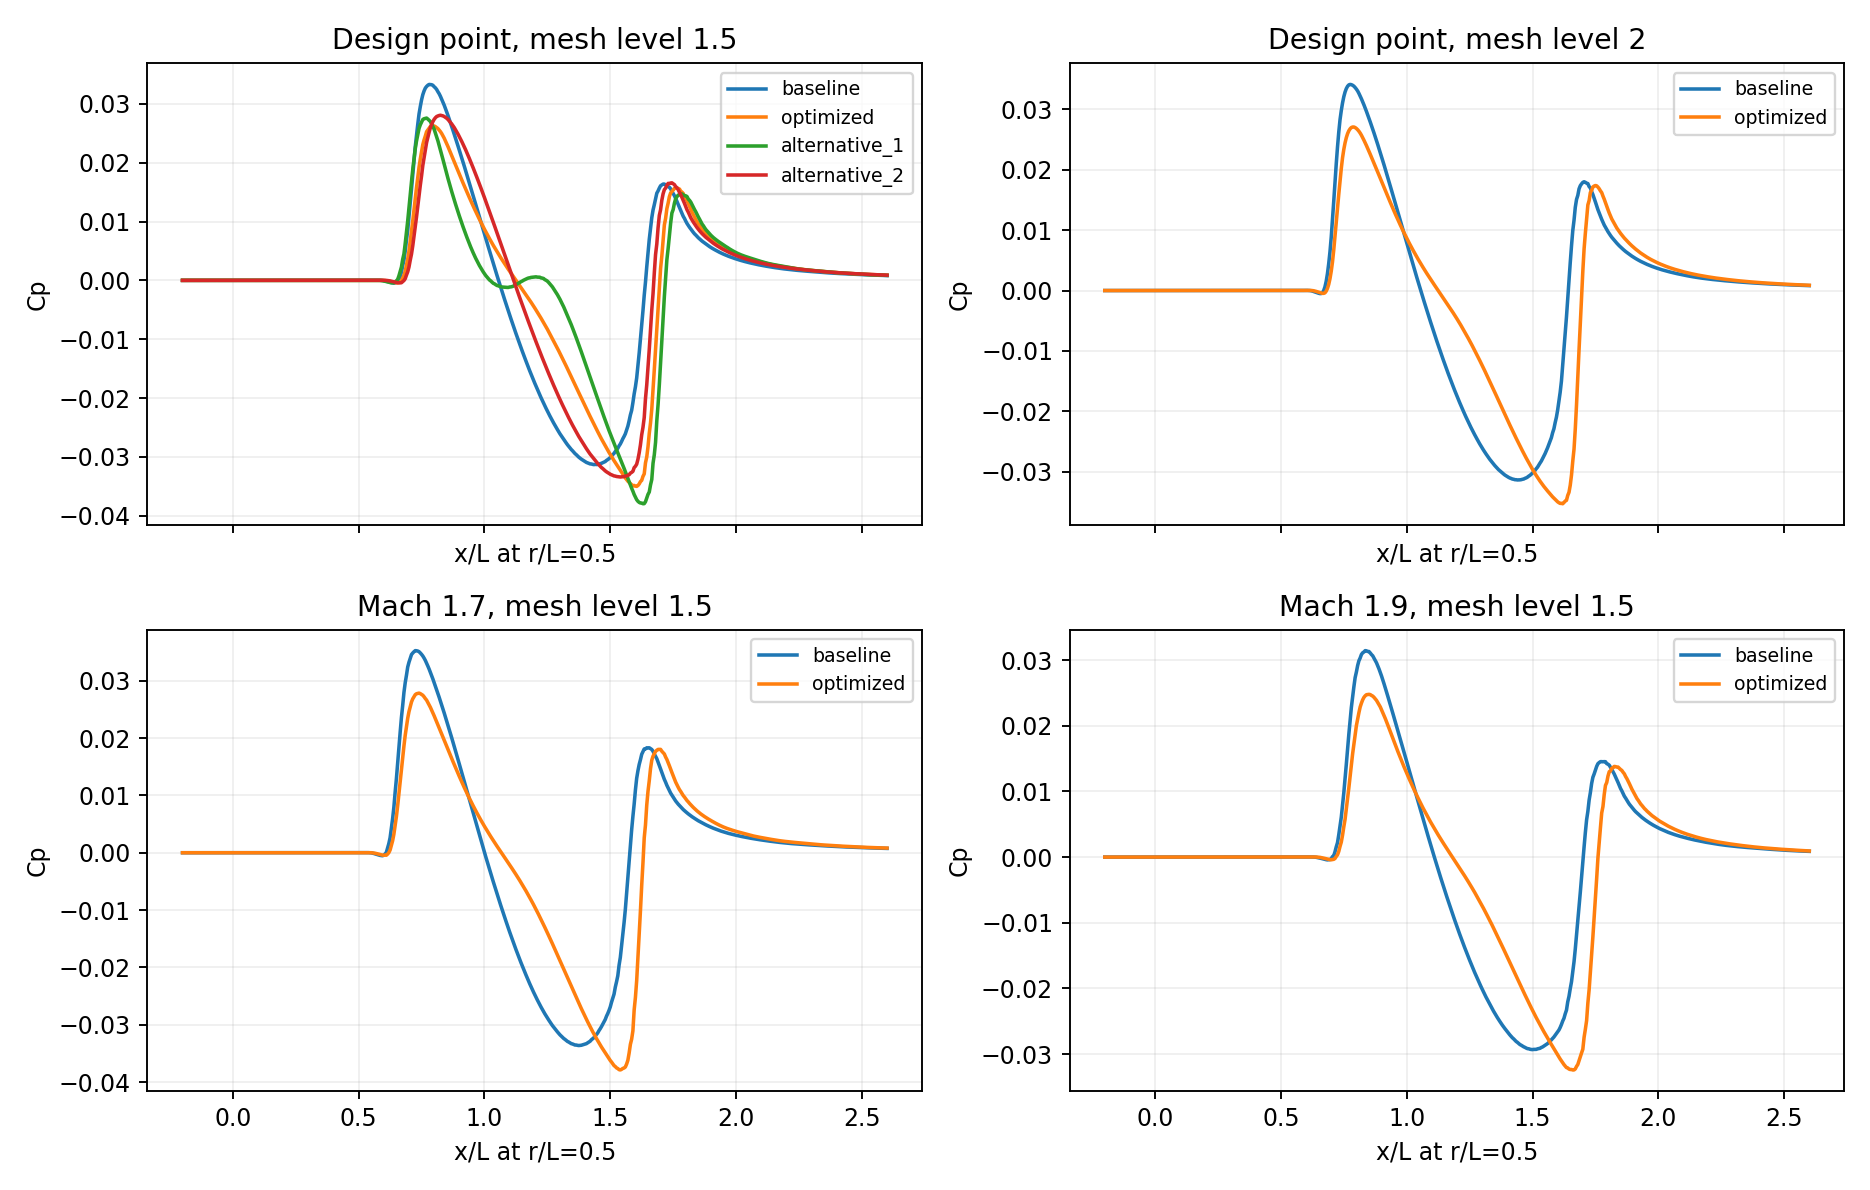

The waveform mesh difference is also reported; the declared mesh gates apply to peak and drag.


In [14]:
design=json.loads((E/'reference/weakwall_design_audit.json').read_text())
path=E/'reference/weakwall_design_test.npz'
assert hashlib.sha256(path.read_bytes()).hexdigest()==design['compact_arrays_sha256']
with np.load(path,allow_pickle=False) as evidence:
    assert list(evidence['names'])==[r['specification']['name'] for r in design['runs']]
    for i,row in enumerate(design['runs']):
        assert np.isclose(evidence['waveforms'][i].max(),row['peak_cp'])
        assert np.isclose(evidence['cd_pressure'][i],row['cd_pressure'])
    for pair in design['design_pairs']:
        i,j=pair['baseline_index'],pair['optimized_index']
        assert np.isclose(1-evidence['waveforms'][j].max()/evidence['waveforms'][i].max(),pair['peak_reduction'])
        assert np.isclose(evidence['cd_pressure'][j]/evidence['cd_pressure'][i],pair['drag_ratio'])
display(pd.DataFrame([dict(level=p['level'],peak_reduction_percent=100*p['peak_reduction'],drag_change_percent=100*p['drag_change'],drag_ratio=p['drag_ratio']) for p in design['design_pairs']]))
display(pd.DataFrame([dict(design=m['design'],peak_mesh_change_percent=100*m['peak_relative_change'],drag_mesh_change_percent=100*m['drag_relative_change'],wave_mesh_change_percent=100*m['wave_relative_l2_change']) for m in design['mesh_sensitivity']]))
display(pd.Series(design['checks'],name='Fresh design acceptance'))
assert design['passed']
display(Image(filename=str(E/'reference/weakwall_design_validation.png')))
print('The waveform mesh difference is also reported; the declared mesh gates apply to peak and drag.')

## 7. Off-design checks
The Mach 1.7 and 1.9 results below are new SU2 8.0.1 calculations of the fixed baseline and retained optimized geometry. The surrogate was trained only at Mach 1.8. These off-design values are CFD results, not surrogate predictions or atmospheric uncertainty estimates. Off-design and alternative runs pass physical and convergence checks; their performance is reported without assuming design-point acceptance.

In [15]:
display(pd.DataFrame([dict(mach=p['mach'],peak_reduction_percent=100*p['peak_reduction'],drag_change_percent=100*p['drag_change']) for p in design['offdesign_pairs']]))
display(pd.DataFrame([dict(case=r['specification']['name'],mach=r['specification']['mach'],cells=r['cells'],iterations=r['checks']['iterations'],max_h0_error_percent=100*max(f['max_h0_relative_deviation'] for f in r['checks']['physical']['fields']),passed=r['checks']['passed']) for r in design['runs']]))

,mach,peak_reduction_percent,drag_change_percent
0,1.7,21.010436,-3.230842
1,1.9,21.166031,-4.310614


,case,mach,cells,iterations,max_h0_error_percent,passed
0,design_v801_000_baseline,1.8,45408,501,4.367492,True
1,design_v801_001_optimized,1.8,45408,501,5.345850,True
2,design_v801_002_baseline,1.8,80640,501,4.397398,True
3,design_v801_003_optimized,1.8,80640,501,5.111463,True
4,design_v801_004_alternative_1,1.8,45408,501,5.549262,True
5,design_v801_005_alternative_2,1.8,45408,501,4.782394,True
6,design_v801_006_baseline,1.7,45408,501,4.332113,True
7,design_v801_007_optimized,1.7,45408,501,4.945999,True
8,design_v801_008_baseline,1.9,45408,501,4.524193,True
9,design_v801_009_optimized,1.9,45408,501,5.176490,True


## 8. Optional: regenerate actual CFD
Install the pinned SU2 and Gmsh versions, set `SU2_CFD`, and follow `cases/week16_lowboom/README.md`. Regeneration commands are deliberately not launched by Run All because they require substantial CPU time. The new generators refuse to overwrite existing run folders or trained weights.

```bash
python qa/week16/install_su2_801.py
# Run in a new checkout/output location to preserve published evidence.
# For each batch index 0 through 10:
python qa/week16/clean_campaign_v801.py --batch 0
# After all eleven batches finish:
python qa/week16/clean_campaign_v801.py --assemble
python qa/week16/clean_model_v801.py --train
python qa/week16/clean_model_v801.py --check-only
```

For a new design, create a unique case name and use `cfd.py --a ... --b ... --level 1.5`, followed by `analyze.py CASE_NAME`. Check convergence and recompute on level 2 before accepting a claim.

## Reflection
1. Why is fixed volume necessary?
2. Which model gives the lowest validation error, and does it also have the lowest extrapolation error?
3. Does a small waveform L2 error guarantee a correct peak?
4. Did the proposed improvement survive grid refinement?
5. What additional equations and data are needed before claiming a quieter sonic boom on the ground?

**References:** Zheng et al. (2026), DOI 10.1016/j.ast.2026.113218; SU2 8.0.1 and 8.5.0 official sources and governing-equation documentation; Gmsh reference manual; Taylor and Maccoll (1933); NASA/AIAA Sonic Boom Prediction Workshops. Detailed links and the independently authored theory are in the lecture source.

## Research appendix: NASA SEEB-ALR reference and failed reproduction
Our SU2 reproduction of the NASA benchmark has not passed acceptance. Further NASA runs are deferred. This appendix preserves the independent sources and the failure lesson; it is not part of the accepted CFD/model evidence for this release.

The NASA body is a separate validation geometry at Mach 1.6. Its original STEP geometry, two wind-tunnel records, coordinate-transform macros and NASA-hosted LAVA computation are retained under `cases/week16_lowboom/reference/`. See [the NASA guide](NASA_REFERENCE_GUIDE.md) for nose geometry, units, sampling position and mesh requirements.

The following cell recomputes the **retained LAVA-versus-experiment** comparison. It is not a new SU2 result or experimental validation of the neural model. The pressure variable is $\Delta p/p_\infty$, related to $C_p$ by $\Delta p/p_\infty=\gamma M^2 C_p/2$. At Mach 1.6 this multiplier is 1.792. Source-prescribed shifts align the coordinates; no fit is used to improve agreement.

In [16]:
from nasa_reference_data import report as nasa_report, load_reference
nasa=nasa_report(write=False)
print(nasa['comparison'])
print('Fixed comparison window [inches]:',nasa['window_inches'])
display(pd.DataFrame(nasa['metrics']).T)
experiments,lava=load_reference()
fig,ax=plt.subplots(figsize=(9,4))
for label,curve in experiments.items():
    plot_mask=(curve['x']>=25)&(curve['x']<=46)
    curve={key:value[plot_mask] for key,value in curve.items()}
    line,=ax.plot(curve['x'],curve['pressure'],label=label)
    ax.fill_between(curve['x'],curve['pressure']-curve['uncertainty'],curve['pressure']+curve['uncertainty'],color=line.get_color(),alpha=.15)
ax.plot(lava['x'],lava['pressure'],'k--',label='NASA-hosted LAVA CFD')
ax.set(xlim=(25,46),xlabel='Source-aligned x [inches]',ylabel='delta p / p infinity')
ax.legend();fig.tight_layout();plt.show()
print(nasa['alignment'])
print(nasa['interpolation'])

Retained NASA-hosted LAVA CFD versus NASA wind-tunnel measurements; not a new SU2 validation.
Fixed comparison window [inches]: [25, 46]


,points,wave_relative_l2,peak_relative_error
NASA run 195,2100.0,0.147478,0.026367
NASA run 553,2100.0,0.150206,0.064060


Original NASA macro shifts only; no fitted amplitude or position.
LAVA repeated axial coordinates averaged, then linear interpolation to experimental points.


### Unaccepted SU2 research result
The attempted NASA calculations did not establish an accepted physically checked, mesh-refined family. Earlier nose treatment produced unphysical stagnation behavior; numerical convergence alone could not establish physical validity. No successful NASA result is required or asserted by this notebook. The retained failure audits and `NASA_REFERENCE_GUIDE.md` document the investigation. Future work must pass geometry, numerical, full-field physical, mesh-sensitivity and experimental-comparison checks before being presented as validation. The accepted results in this release are the teaching-body CFD/model checks and the Taylor-Maccoll cone verification.